# 04 — Predictive Model (Bonus)

Logistic regression predicting whether a sourced candidate will be placed.

**Class imbalance fix:** only ~9% of candidates are placed. A vanilla model 
ignores the minority class entirely and scores 90% accuracy by predicting
'Not Placed' for everyone. Two fixes applied:
1. `class_weight='balanced'` — upweights the minority class during training.
2. **Threshold tuning** — the default 0.50 cut-off is wrong for a 9% base rate;
   we select the threshold that maximises F1 on the Placed class.

The emphasis remains on **coefficient interpretation** — translating model weights
into plain business language.

Run notebooks 01–03 first.


In [1]:
import sqlite3
import pickle
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

CHARTS_DIR = Path("../outputs/charts")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = "../database/recruitment.db"
conn = sqlite3.connect(DB_PATH)

candidates = pd.read_sql("SELECT * FROM candidates_clean", conn)
pipeline   = pd.read_sql("SELECT * FROM pipeline_stages",  conn)
roles      = pd.read_sql("SELECT * FROM roles",            conn)
clients    = pd.read_sql("SELECT * FROM clients",          conn)

roles_ext = roles.merge(clients[['client_id', 'industry']], on='client_id')
conn.close()

print(f"Candidates: {len(candidates):,}")

Candidates: 1,000


## 1. Feature engineering

In [2]:
# Target: was the candidate ever Placed?
placed_ids = set(pipeline.loc[pipeline['stage'] == 'Placed', 'candidate_id'])
candidates['placed'] = candidates['candidate_id'].isin(placed_ids).astype(int)

# Feature: salary alignment — how does expected salary compare to the role's band?
# Join each candidate to the role they were sourced for via pipeline (first Sourced row)
first_role = (
    pipeline[pipeline['stage'] == 'Sourced']
    .sort_values('stage_id')
    .groupby('candidate_id')[['role_id', 'recruiter']]
    .first()
    .reset_index()
)
first_role = first_role.merge(
    roles_ext[['role_id', 'salary_band_min', 'salary_band_max', 'industry']],
    on='role_id', how='left'
)
df = candidates.merge(first_role, on='candidate_id', how='left')

df['salary_midpoint'] = (df['salary_band_min'] + df['salary_band_max']) / 2
# Positive = candidate expects more than midpoint; negative = expects less
df['salary_gap'] = df['expected_salary'] - df['salary_midpoint']

print(df[['candidate_id', 'source_channel', 'years_experience',
           'salary_gap', 'recruiter', 'placed']].head(6).to_string())

   candidate_id   source_channel  years_experience  salary_gap        recruiter  placed
0             1        Job Board               6.0      2500.0  Dave O'Sullivan       0
1             2         LinkedIn               4.0     -1000.0  Dave O'Sullivan       0
2             3    Cold Outreach              13.0     13000.0      Marcus Chen       0
3             4        Job Board              13.0    -32500.0      Marcus Chen       0
4             5         Referral              10.0       500.0      Marcus Chen       0
5             6  Agency Database              15.0     -4500.0      Sarah Kelly       0


## 2. Prepare model features

In [3]:
features = ['source_channel', 'years_experience', 'salary_gap', 'recruiter']
target   = 'placed'

model_df = df[features + [target]].dropna()
print(f"Modelling rows: {len(model_df):,}  |  Placement rate: {model_df[target].mean():.1%}")

# One-hot encode categoricals (drop_first avoids multicollinearity)
X = pd.get_dummies(model_df[features], columns=['source_channel', 'recruiter'], drop_first=True)
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Modelling rows: 1,000  |  Placement rate: 11.0%
Train: 800  |  Test: 200


## 3. Train logistic regression

In [4]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx    = f1_scores.argmax()
best_thresh = thresholds[best_idx]

y_pred  = (y_prob >= best_thresh).astype(int)
roc_auc  = roc_auc_score(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

print('Threshold (tuned): ', round(best_thresh, 2), ' (default was 0.50)')
print('ROC-AUC:           ', round(roc_auc, 3))
print('Avg Precision (PR):', round(avg_prec, 3))
print('Accuracy:          ', f'{accuracy_score(y_test, y_pred):.1%}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed'], zero_division=0))


Threshold (tuned):  0.38  (default was 0.50)
ROC-AUC:            0.65
Avg Precision (PR): 0.206
Accuracy:           48.5%

              precision    recall  f1-score   support

  Not Placed       0.97      0.43      0.60       178
      Placed       0.17      0.91      0.28        22

    accuracy                           0.48       200
   macro avg       0.57      0.67      0.44       200
weighted avg       0.89      0.48      0.56       200



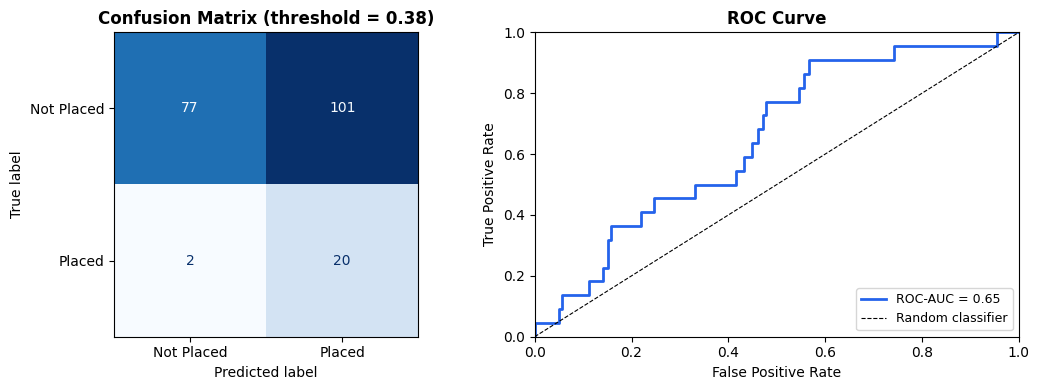

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Placed', 'Placed']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
cm_title = 'Confusion Matrix (threshold = ' + str(round(best_thresh, 2)) + ')'
axes[0].set_title(cm_title, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_label = 'ROC-AUC = ' + str(round(roc_auc, 3))
axes[1].plot(fpr, tpr, color='#2563EB', lw=2, label=roc_label)
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(CHARTS_DIR / '06_confusion_matrix.png', bbox_inches='tight')
plt.show()


## 4. Coefficient interpretation — the business story

In [6]:
lr_model = clf.named_steps['lr']
coef_df  = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': lr_model.coef_[0],
    'odds_ratio':  np.exp(lr_model.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print(coef_df.to_string(index=False))

                     feature  coefficient  odds_ratio
     source_channel_Referral     0.442956    1.557304
                  salary_gap     0.090062    1.094242
            years_experience    -0.004017    0.995991
     source_channel_LinkedIn    -0.023080    0.977184
       recruiter_Marcus Chen    -0.036129    0.964516
       recruiter_Sarah Kelly    -0.138101    0.871011
        recruiter_Priya Nair    -0.216731    0.805146
    source_channel_Job Board    -0.346912    0.706868
source_channel_Cold Outreach    -0.417862    0.658453


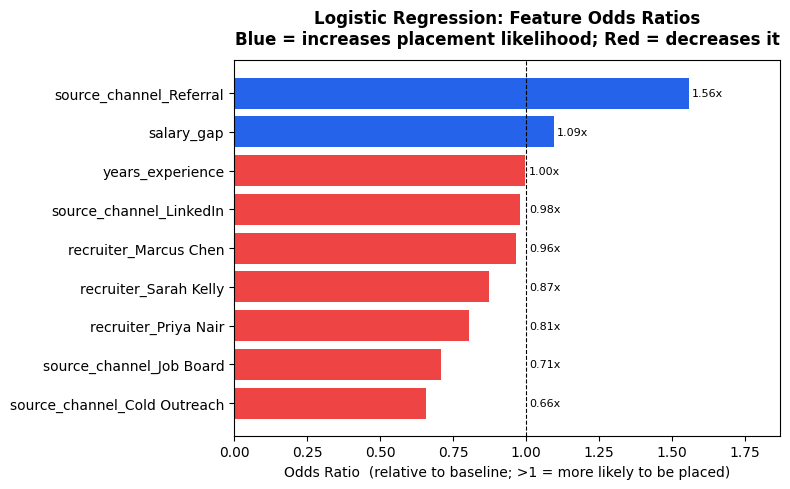

Saved: 07_odds_ratios.png


In [7]:
# Chart: odds ratios (>1 = increases probability of placement; <1 = decreases it)
coef_plot = coef_df.set_index('feature').sort_values('odds_ratio')
colours   = ['#2563EB' if v >= 1 else '#EF4444' for v in coef_plot['odds_ratio']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(coef_plot.index, coef_plot['odds_ratio'], color=colours)
ax.axvline(1.0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, coef_plot['odds_ratio']):
    ax.text(max(val, 1.0) + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}x', va='center', fontsize=8)

ax.set_xlabel('Odds Ratio  (relative to baseline; >1 = more likely to be placed)')
ax.set_title('Logistic Regression: Feature Odds Ratios\nBlue = increases placement likelihood; Red = decreases it',
             fontweight='bold', pad=12)
ax.set_xlim(0, coef_plot['odds_ratio'].max() * 1.2)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '07_odds_ratios.png', bbox_inches='tight')
plt.show()
print("Saved: 07_odds_ratios.png")

## 5. Save model

In [8]:
with open(MODELS_DIR / 'placement_model.pkl', 'wb') as f:
    pickle.dump({'model': clf, 'feature_columns': list(X.columns)}, f)
print("Model saved to models/placement_model.pkl")

Model saved to models/placement_model.pkl
